# Preparación de entorno

In [3]:
# Manejo de archivos y carpetas
import os

# Computación numérica
import numpy as np

# Librería para gráficos
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D  # Gráficos 3D

# Mostrar gráficos dentro del notebook
%matplotlib inline

In [4]:
# Conectar Google Drive
from google.colab import drive
drive.mount("/content/gdrive")

Mounted at /content/gdrive


# Preparar datos

In [5]:
# Librerías
import pandas as pd

# Cargar dataset
data = pd.read_csv("/content/gdrive/MyDrive/SIS420/datasets/datasets_tareas/train.csv")

# ── Transformaciones necesarias ──────────────────────────────────────────────

# 1. time → extraer hora como número entero
data['time_hour'] = data['time'].str.split(':').str[0].astype(int)

# 2. car_value (a-g) → ordinal numérico
car_value_map = {'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7}
data['car_value_num'] = data['car_value'].map(car_value_map)

# 3. state → one-hot encoding
state_dummies = pd.get_dummies(data['state'], prefix='state')
data = pd.concat([data, state_dummies], axis=1)

# ── Selección de 25 atributos para X ────────────────────────────────────────
state_cols = list(state_dummies.columns[:5])  # 5 columnas de state

feature_cols = [
    'shopping_pt',       # punto de compra (sesión)
    'record_type',       # 0=cotización, 1=compra
    'day',               # día de la semana
    'time_hour',         # hora de la consulta
    'group_size',        # tamaño del grupo asegurado
    'homeowner',         # es propietario de casa (0/1)
    'car_age',           # edad del vehículo
    'car_value_num',     # valor del auto
    'risk_factor',       # factor de riesgo
    'age_oldest',        # edad del conductor mayor
    'age_youngest',      # edad del conductor menor
    'married_couple',    # pareja casada (0/1)
    'C_previous',        # cobertura C anterior
    'duration_previous', # duración del plan anterior
    'A',                 # opción de cobertura A
    'B',                 # opción de cobertura B
    'C',                 # opción de cobertura C
    'D',                 # opción de cobertura D
    'E',                 # opción de cobertura E
    'F',                 # opción de cobertura F
] + state_cols           # + 5 columnas de state = 25 total

# Manejar valores nulos con la media de cada columna
data_clean = data[feature_cols + ['cost']].copy()

for col in feature_cols:
    if data_clean[col].isnull().any():
        media = data_clean[col].mean()
        data_clean[col] = data_clean[col].fillna(media)
        print(f"  '{col}': nulos reemplazados con media={media:.2f}")

print(f"Nulos restantes: {data_clean.isnull().sum().sum()}")

# Armar X e y como arrays numpy
X = data_clean[feature_cols].values
y = data_clean['cost'].values

# Cantidad de registros
m = y.size
print("\nNúmero de registros:", m)
print("\nPrimeros 10 registros usados en la regresión:\n")

# Imprimir atributos + variable objetivo
print(data_clean[feature_cols + ['cost']].head(10))

  'car_value_num': nulos reemplazados con media=5.33
  'risk_factor': nulos reemplazados con media=2.56
  'C_previous': nulos reemplazados con media=2.44
  'duration_previous': nulos reemplazados con media=6.00
Nulos restantes: 0

Número de registros: 665249

Primeros 10 registros usados en la regresión:

   shopping_pt  record_type  day  time_hour  group_size  homeowner  car_age  \
0            1            0    0          8           2          0        2   
1            2            0    0          8           2          0        2   
2            3            0    0          8           2          0        2   
3            4            0    0          8           2          0        2   
4            5            0    0         11           2          0        2   
5            6            0    0         11           2          0        2   
6            7            0    0         11           2          0        2   
7            8            0    0         12           2      

# Función de Normalización

In [6]:
def  featureNormalize(X):

    X_norm = X.copy()
    mu = np.zeros(X.shape[1]) # Número de columnas (atributos)
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis = 0) # Calcula la media por columna mu = [media1, media2, media3, ..., media11]
    sigma = np.std(X, axis = 0) # Calcula desviación estándar sigma = [std1, std2, std3, ..., std11]
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [7]:
# Aplicar la función
X = X.astype(float)
X_norm, mu, sigma = featureNormalize(X)

# Datos originales
#print(X)

print('Media calculada:', mu)
print('Desviación estandar calculada:', sigma)

# Datos normalizados
#print(X_norm)

Media calculada: [4.21996576e+00 1.45823594e-01 1.96942949e+00 1.26664482e+01
 1.23478427e+00 5.36229292e-01 8.13943651e+00 5.33264305e+00
 2.56399604e+00 4.49924028e+01 4.25775882e+01 2.09781601e-01
 2.44471787e+00 6.00377395e+00 9.27545926e-01 4.54235933e-01
 2.27526535e+00 2.45429907e+00 4.45192702e-01 1.16276763e+00
 3.54153107e-02 1.57234359e-02 3.66915245e-02 2.90913628e-02
 5.63398066e-03]
Desviación estandar calculada: [ 2.39436697  0.35292928  1.45346941  2.71353723  0.46103532  0.49868571
  5.7645937   1.04554291  0.88829598 17.40342688 17.46041925  0.40715265
  1.01994219  4.61449314  0.59522094  0.49790125  0.99079748  0.75395228
  0.49698708  0.94359308  0.18482713  0.12440341  0.18800334  0.16806265
  0.07484811]


# Intersección Columnas de unos

In [8]:
# Añade el termino de interseccion a X
# (Columna de unos para X0)
X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

# Imprimir y ver la columna de unos
# print(X)

print("Dimensión de X:", X.shape)

Dimensión de X: (665249, 26)


# Descenso de Gradiente

In [9]:
def computeCostMulti(X, y, theta):

    # Inicializa algunos valores
    m = y.shape[0] # Cant, de registros

    J = 0

    # h = np.dot(X, theta)

    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))

    return J


In [10]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):

    # Inicializa algunos valores
    m = y.shape[0] # Cant, de registros

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente

    theta = theta.copy()

    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

# Coeficiente de aprendizaje

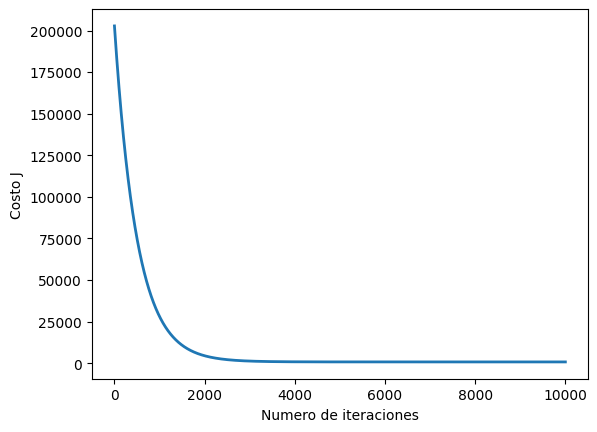

theta calculado por el descenso por el gradiente: [ 6.35756288e+02  1.40199185e+00 -1.19198688e+00  2.38531069e-01
 -1.19932669e+00  3.13184288e+00 -7.14658262e+00 -7.20393430e+00
  1.43146428e+00  3.01937879e+00  2.47433298e+00 -8.47744634e+00
 -4.07648546e+00 -4.92406048e+00 -4.69224774e+00  1.17008582e+01
  1.92736054e-01  2.50646722e-01 -1.03435669e+00  8.62013491e+00
 -2.78905145e+00 -1.85542154e+00 -7.23704458e-01 -1.20740575e+00
  8.41778573e-01  1.53766477e+00]


In [11]:
# Elegir algun valor para alpha (probar varias alternativas)
alpha = 0.001 # alpha = 0.003
num_iters = 10000

# inicializa theta y ejecuta el descenso por el gradiente
theta = np.zeros(X.shape[1])

# Ejecutar descenso de gradiente
theta, J_history = gradientDescentMulti(X, y, theta, alpha, num_iters)

# Grafica la convergencia del costo
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')
pyplot.show()

# Muestra los resultados del descenso por el gradiente
print('theta calculado por el descenso por el gradiente: {:s}'.format(str(theta)))

# 100 Predicciones con Regresión Polinómica

In [12]:
# 100 predicciones

# Tomar 100 muestras aleatorias del dataset
indices = np.random.choice(m, 100, replace=False)
X_muestra = data_clean[feature_cols].values[indices].astype(float)
y_real = y[indices]

# Normalizar con la misma mu y sigma del entrenamiento
X_muestra_norm = (X_muestra - mu) / sigma

# Agregar columna de unos (término de intersección)
X_muestra_norm = np.concatenate([np.ones((100, 1)), X_muestra_norm], axis=1)

# Realizar predicciones
predicciones = X_muestra_norm.dot(theta)

# Mostrar resultados
print('{:>10s}{:>15s}{:>15s}{:>15s}'.format('Muestra', 'Predicción', 'Real', 'Diferencia'))
print('-' * 55)
for i in range(100):
    diff = predicciones[i] - y_real[i]
    print('{:>10d}{:>15.2f}{:>15.2f}{:>15.2f}'.format(i+1, predicciones[i], y_real[i], diff))

# Error promedio
error_promedio = np.mean(np.abs(predicciones - y_real))
print(f"\nError absoluto promedio: {error_promedio:.2f}")
print(f"Costo en las 100 muestras: {computeCostMulti(X_muestra_norm, y_real, theta):.2f}")

   Muestra     Predicción           Real     Diferencia
-------------------------------------------------------
         1         649.19         651.00          -1.81
         2         624.28         618.00           6.28
         3         618.02         651.00         -32.98
         4         650.94         696.00         -45.06
         5         661.78         683.00         -21.22
         6         636.98         664.00         -27.02
         7         636.18         641.00          -4.82
         8         620.55         617.00           3.55
         9         618.66         631.00         -12.34
        10         582.63         525.00          57.63
        11         648.85         619.00          29.85
        12         642.10         674.00         -31.90
        13         572.80         576.00          -3.20
        14         647.83         640.00           7.83
        15         599.29         564.00          35.29
        16         629.22         580.00        

# Ecuación Normal

In [13]:
# Cargar datos
data_en = data_clean[feature_cols + ['cost']].copy()

X_en = data_en[feature_cols].values.astype(float)
y_en = data_en['cost'].values
m_en = y_en.size

print(m_en)

X_en = np.concatenate([np.ones((m_en, 1)), X_en], axis=1)

665249


In [14]:
def normalEqn(X, y):

    theta = np.zeros(X.shape[1])

    theta = np.dot(np.dot(np.linalg.pinv(np.dot(X.T, X)), X.T), y)

    return theta

In [15]:
# Calcula los parametros con la ecuación de la normal
theta_normal = normalEqn(X_en, y_en)

# Muestra los resultados obtenidos a partir de la aplicación de la ecuación de la normal
print('Theta calculado a partir de la ecuación de la normal: {:s}'.format(str(theta_normal)))

# Estimar el costo para un ejemplo con valores específicos
# [1, shopping_pt, record_type, day, time_hour, group_size, homeowner, car_age,
#  car_value_num, risk_factor, age_oldest, age_youngest, married_couple,
#  C_previous, duration_previous, A, B, C, D, E, F, state_col1..5]

X_array = [1, 2, 0, 0, 8, 2, 0, 3, 5, 2, 45, 30, 1, 2, 6, 1, 0, 2, 2, 1, 2, 0, 1, 0, 0, 1]
cost_pred = np.dot(X_array, theta_normal)

print('Costo predecido para el ejemplo dado (usando la ecuación de la normal): ${:.0f}'.format(cost_pred))

Theta calculado a partir de la ecuación de la normal: [ 6.51724281e+02  5.75497011e-01 -3.38010023e+00  1.53214227e-01
 -4.46150554e-01  1.66846556e+00 -1.46357428e+01 -1.24852761e+00
  1.43863569e+00  3.39411582e+00  5.26464303e-01 -8.60215483e-01
 -7.58001695e+00 -4.86292728e+00 -1.04331840e+00  1.97854305e+01
  3.24429585e-01  4.36638652e-01 -1.46334669e+00  1.73346070e+01
 -2.97733029e+00 -1.00614807e+01 -5.81822553e+00 -6.33149729e+00
  4.78825192e+00  2.06291025e+01]
Costo predecido para el ejemplo dado (usando la ecuación de la normal): $681


# 100 Predicciones con Ecuación Normal

In [16]:
# 100 predicciones con ecuación normal

# Tomar 100 muestras aleatorias del dataset
indices = np.random.choice(m_en, 100, replace=False)
X_muestra = X_en[indices]
y_real = y_en[indices]

# Realizar predicciones (X_en ya tiene la columna de unos, no necesita normalización)
predicciones = X_muestra.dot(theta_normal)

# Mostrar resultados
print('{:>10s}{:>15s}{:>15s}{:>15s}'.format('Muestra', 'Predicción', 'Real', 'Diferencia'))
print('-' * 55)
for i in range(100):
    diff = predicciones[i] - y_real[i]
    print('{:>10d}{:>15.2f}{:>15.2f}{:>15.2f}'.format(i+1, predicciones[i], y_real[i], diff))

# Error promedio
error_promedio = np.mean(np.abs(predicciones - y_real))
print(f"\nError absoluto promedio: {error_promedio:.2f}")
print(f"Costo en las 100 muestras: {computeCostMulti(X_muestra, y_real, theta_normal):.2f}")

   Muestra     Predicción           Real     Diferencia
-------------------------------------------------------
         1         622.03         638.00         -15.97
         2         633.81         612.00          21.81
         3         667.29         624.00          43.29
         4         670.38         612.00          58.38
         5         639.49         647.00          -7.51
         6         619.44         597.00          22.44
         7         629.45         653.00         -23.55
         8         610.05         535.00          75.05
         9         615.16         594.00          21.16
        10         642.08         741.00         -98.92
        11         623.14         572.00          51.14
        12         610.94         611.00          -0.06
        13         641.82         628.00          13.82
        14         641.07         633.00           8.07
        15         632.75         629.00           3.75
        16         632.57         614.00        

# Regresión Polinomica

In [22]:
# ── Regresión Polinómica ─────────────────────────────────────────────────────

# Tomar X sin la columna de unos (datos originales sin normalizar)
X_pol = data_clean[feature_cols].values.astype(float)
y_pol = data_clean['cost'].values
m_pol = y_pol.size

# Agregar términos cuadráticos (X² para cada columna)
X_pol = np.concatenate([X_pol, X_pol * X_pol], axis=1)

print("Dimensión de X polinómica (antes de normalizar):", X_pol.shape)

Dimensión de X polinómica (antes de normalizar): (665249, 50)


In [23]:
# Normalizar
X_pol_norm, mu_pol, sigma_pol = featureNormalize(X_pol)

print('Media calculada:', mu_pol)
print('Desviación estándar calculada:', sigma_pol)

Media calculada: [4.21996576e+00 1.45823594e-01 1.96942949e+00 1.26664482e+01
 1.23478427e+00 5.36229292e-01 8.13943651e+00 5.33264305e+00
 2.56399604e+00 4.49924028e+01 4.25775882e+01 2.09781601e-01
 2.44471787e+00 6.00377395e+00 9.27545926e-01 4.54235933e-01
 2.27526535e+00 2.45429907e+00 4.45192702e-01 1.16276763e+00
 3.54153107e-02 1.57234359e-02 3.66915245e-02 2.90913628e-02
 5.63398066e-03 2.35411042e+01 1.45823594e-01 5.99122584e+00
 1.67802194e+02 1.73724575e+00 5.36229292e-01 9.94809673e+01
 2.95302419e+01 7.36314542e+00 2.32719558e+03 2.11771726e+03
 2.09781601e-01 7.01692752e+00 5.73388485e+01 1.21462941e+00
 4.54235933e-01 6.15851208e+00 6.59202795e+00 4.45192702e-01
 2.24239646e+00 3.54153107e-02 1.57234359e-02 3.66915245e-02
 2.90913628e-02 5.63398066e-03]
Desviación estándar calculada: [2.39436697e+00 3.52929275e-01 1.45346941e+00 2.71353723e+00
 4.61035316e-01 4.98685711e-01 5.76459370e+00 1.04554291e+00
 8.88295977e-01 1.74034269e+01 1.74604192e+01 4.07152650e-01
 1.01

Dimensión de X polinómica (final): (665249, 51)


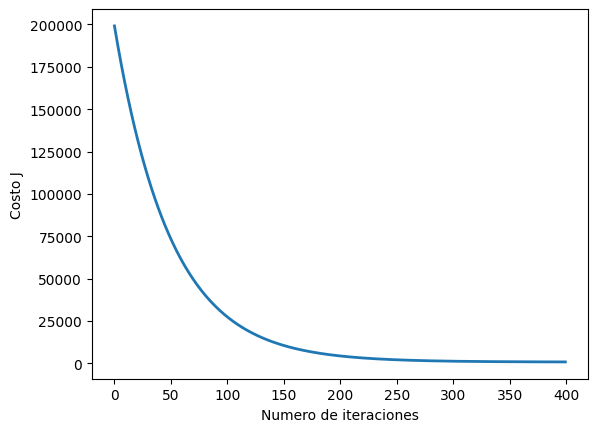

theta calculado por el descenso por el gradiente (polinómica): [ 6.24372316e+02  8.91728043e-01 -5.98044130e-01 -1.40516368e-01
 -5.28526495e-01  1.19572971e+00 -3.66063207e+00 -6.47499598e+00
  6.11447999e-01  2.59162679e+00 -6.40011658e-01 -5.38385182e+00
 -2.04537069e+00 -2.91380669e+00 -3.42286761e+00  9.79887699e+00
  8.05599203e-02 -2.48416454e-01 -4.27230126e-01  4.47184499e+00
 -1.65445542e-01 -9.56820724e-01 -3.51570759e-01 -5.97261581e-01
  5.37894433e-01  7.51006363e-01  5.22966663e-01 -5.98044130e-01
  4.85320961e-01 -6.22500065e-01  2.33136874e+00 -3.66063207e+00
 -5.87458394e-01  9.52645696e-01  6.21774050e-02  2.06031147e+00
 -1.77815494e+00 -2.04537069e+00 -1.89162443e+00 -1.14871131e+00
  2.53155696e-01  8.05599203e-02  7.30670577e-01 -6.89697936e-01
  4.47184499e+00 -1.73391287e+00 -9.56820724e-01 -3.51570759e-01
 -5.97261581e-01  5.37894433e-01  7.51006363e-01]


In [24]:
# Agregar término de intersección
X_pol_norm = np.concatenate([np.ones((m_pol, 1)), X_pol_norm], axis=1)

print("Dimensión de X polinómica (final):", X_pol_norm.shape)

# Alpha y iteraciones
alpha = 0.01
num_iters = 400

# Inicializar theta (ahora son 51 parámetros: 1 sesgo + 25*2 columnas)
theta_pol = np.zeros(X_pol_norm.shape[1])

# Ejecutar descenso de gradiente
theta_pol, J_history_pol = gradientDescentMulti(X_pol_norm, y_pol, theta_pol, alpha, num_iters)

# Graficar convergencia
pyplot.plot(np.arange(len(J_history_pol)), J_history_pol, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')
pyplot.show()

print('theta calculado por el descenso por el gradiente (polinómica): {:s}'.format(str(theta_pol)))

In [27]:
# ── Ecuación normal polinómica ───────────────────────────────────────────────
X_pol_en = data_clean[feature_cols].values.astype(float)
X_pol_en = np.concatenate([X_pol_en, X_pol_en * X_pol_en], axis=1)
X_pol_en = np.concatenate([np.ones((m_pol, 1)), X_pol_en], axis=1)

print("Dimensión de X polinómica ecuación normal:", X_pol_en.shape)

theta_pol_normal = normalEqn(X_pol_en, y_pol)
print('Theta calculado por la ecuación normal (polinómica): {:s}'.format(str(theta_pol_normal)))

Dimensión de X polinómica ecuación normal: (665249, 51)
Theta calculado por la ecuación normal (polinómica): [ 6.71554969e+02  1.00592599e+00 -1.52676550e+00 -1.06005385e+00
  1.61533732e-01 -1.24411933e+01 -6.60213863e+00 -1.57810869e+00
  1.91496984e+00  2.37812124e+01 -8.58199290e-02 -2.38101304e+00
 -2.87044837e+00 -5.57021028e+00 -2.41540092e+00  6.51300933e+01
  1.23848491e-01 -1.04965328e+01  7.02136970e+00  6.99698239e+00
 -1.80673922e+01 -5.62253798e+00 -3.30155017e+00 -3.07160846e+00
 -1.16450786e+00  1.10929368e+01 -3.42884034e-02 -1.52676395e+00
  3.11912033e-01 -2.30212176e-02  3.91359974e+00 -6.60213863e+00
  2.75990579e-02  1.07624514e-02 -3.68828620e+00  5.46101872e-03
  1.76191646e-02 -2.87044837e+00  2.21319578e-02  8.95344723e-02
 -2.11825241e+01  1.23848491e-01  2.23779105e+00 -1.97160393e+00
  6.99698239e+00  4.65592260e+00 -5.62253798e+00 -3.30155017e+00
 -3.07160846e+00 -1.16450786e+00  1.10929368e+01]


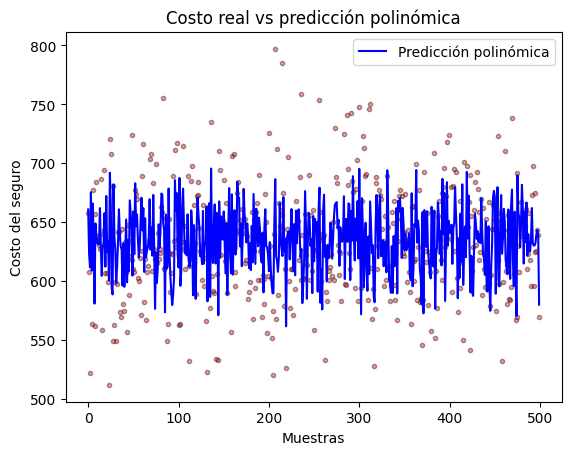

In [28]:
def plotData(x, y):
    fig = pyplot.figure()

    pyplot.plot(x, y, 'ro', ms=3, mec='k', alpha=0.4)
    pyplot.xlabel('Muestras')
    pyplot.ylabel('Costo del seguro')
    pyplot.title('Costo real vs predicción polinómica')

# Reconstruir X_pol_en
X_pol_en = data_clean[feature_cols].values.astype(float)
X_pol_en = np.concatenate([X_pol_en, X_pol_en * X_pol_en], axis=1)
X_pol_en = np.concatenate([np.ones((m_pol, 1)), X_pol_en], axis=1)

# Tomar 500 muestras para que el gráfico sea legible
indices_plot = np.random.choice(m_pol, 500, replace=False)
x_plot = np.arange(500)
y_plot_real = y_pol[indices_plot]
y_plot_pred = X_pol_en[indices_plot].dot(theta_pol_normal)

plotData(x_plot, y_plot_real)
pyplot.plot(x_plot, y_plot_pred, 'b-', lw=1.5, label='Predicción polinómica')
pyplot.legend()
pyplot.show()